In [74]:
import sys 
print(sys.executable)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import re, math
from urllib.parse import urlparse, unquote

base_dataset = pd.read_csv(r"C:\Users\puthi\OneDrive - Swinburne University\Documents\malicious_phish.csv") 

base_dataset["label"] = (base_dataset["type"] == "phishing").astype(int)

print("Total rows:", len(base_dataset))
print("\nBinary label counts:")
print(base_dataset["label"].value_counts())
print("\nOriginal type counts:")
print(base_dataset["type"].value_counts())
print("\nMissing URLs:", base_dataset["url"].isna().sum())
print("Duplicate URLs:", base_dataset["url"].duplicated().sum())

c:\Users\puthi\AppData\Local\Programs\Python\Python313\python.exe
Total rows: 651191

Binary label counts:
label
0    557080
1     94111
Name: count, dtype: int64

Original type counts:
type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64

Missing URLs: 0
Duplicate URLs: 10072


In [75]:
print("Shape:", base_dataset.shape)
print("\nColumns:", base_dataset.columns.tolist())
print("\nFirst 5 rows:")
print(base_dataset.head())
print("\nLabel counts:")
print(base_dataset.iloc[:, -1].value_counts())

Shape: (651191, 3)

Columns: ['url', 'type', 'label']

First 5 rows:
                                                 url        type  label
0                                   br-icloud.com.br    phishing      1
1                mp3raid.com/music/krizz_kaliko.html      benign      0
2                    bopsecrets.org/rexroth/cr/1.htm      benign      0
3  http://www.garage-pirenne.be/index.php?option=...  defacement      0
4  http://adventure-nicaragua.net/index.php?optio...  defacement      0

Label counts:
label
0    557080
1     94111
Name: count, dtype: int64


In [76]:
#drop missing labels 
base_dataset = base_dataset.dropna(subset=["url"]).reset_index(drop=True)

#drop duplicate URLs
before = len(base_dataset)
base_dataset = base_dataset.drop_duplicates(subset="url").reset_index(drop=True)
after = len(base_dataset)
print(f"Removed {before - after} duplicate URLs")
print(f"Remaining rows: {after}")
print(base_dataset["label"].value_counts())


Removed 10072 duplicate URLs
Remaining rows: 641119
label
0    547033
1     94086
Name: count, dtype: int64


In [119]:
#Normalizes the URL into a standard format for processing
def normalize(url):

    if not isinstance(url, str):
        return ""
    url = url.strip()
    try:
        url = unquote(url)
    except Exception: 
        pass
    if "://" not in url:
        url = "http://" + url
    try:
        parsed = urlparse(url)
        scheme = parsed.scheme.lower()
        host = parsed.netloc.lower()
        path = parsed.path 
        query = parsed.query 
        return f"{scheme}://{host}{path}" + (f"?{query}" if query else "")
    except ValueError:
        return ""



for i in range(5):
    print(f"Row {i}:")
    print("  Original:", base_dataset["url"].iloc[i])
    print("  Cleaned:  ", base_dataset["url_clean"].iloc[i])
    print()

Row 0:
  Original: br-icloud.com.br
  Cleaned:   http://br-icloud.com.br

Row 1:
  Original: mp3raid.com/music/krizz_kaliko.html
  Cleaned:   http://mp3raid.com/music/krizz_kaliko.html

Row 2:
  Original: bopsecrets.org/rexroth/cr/1.htm
  Cleaned:   http://bopsecrets.org/rexroth/cr/1.htm

Row 3:
  Original: http://www.garage-pirenne.be/index.php?option=com_content&view=article&id=70&vsig70_0=15
  Cleaned:   http://www.garage-pirenne.be/index.php?option=com_content&view=article&id=70&vsig70_0=15

Row 4:
  Original: http://adventure-nicaragua.net/index.php?option=com_mailto&tmpl=component&link=aHR0cDovL2FkdmVudHVyZS1uaWNhcmFndWEubmV0L2luZGV4LnBocD9vcHRpb249Y29tX2NvbnRlbnQmdmlldz1hcnRpY2xlJmlkPTQ3OmFib3V0JmNhdGlkPTM2OmRlbW8tYXJ0aWNsZXMmSXRlbWlkPTU0
  Cleaned:   http://adventure-nicaragua.net/index.php?option=com_mailto&tmpl=component&link=aHR0cDovL2FkdmVudHVyZS1uaWNhcmFndWEubmV0L2luZGV4LnBocD9vcHRpb249Y29tX2NvbnRlbnQmdmlldz1hcnRpY2xlJmlkPTQ3OmFib3V0JmNhdGlkPTM2OmRlbW8tYXJ0aWNsZXMmSXRlbWlk

In [ ]:
#Saves the base dataset to a csv file 
base_dataset.to_csv("base_dataset_normalized.csv", index=False)
print("Saved base_dataset_normalized.csv")
print("Rows:", len(base_dataset), " Columns:", base_dataset.columns.tolist())
print("URLs that failed to parse:", (base_dataset["url_clean"] == "").sum())

Saved base_dataset_normalized.csv
Rows: 641119  Columns: ['url', 'type', 'label', 'url_clean']
URLs that failed to parse: 17


In [ ]:
#Define the suspicious entities, and extracting features from the dataset 
suspicious_words = [
    "verify", "account", "login", "update", "secure", "banking", "confirm", 
    "password", "security", "signin", "support", "service", "auth", "authenticate",
    "winner", "prize", "websrc"
]

suspicious_tlds = {
    "tk", "ml", "ga", "xyz", "top", "icu", "sbs", "cfd", "zip", "move"
}

companies = ["amazon", "paypal", "microsoft","apple", "twitter", "facebook", "google", "netflix", "bank"]


def extract_features(url):
    parsed = urlparse(url)
    host = parsed.netloc
    path = parsed.path
    url_lower = url.lower()
    host_no_port = host.split(":")[0]


    has_ip = int(bool(re.match(r"^\d{1,3}(\.\d{1,3}){3}$", host_no_port)))

    parts = host_no_port.split(".")
    tld = parts[-1] if len(parts) > 1 else ""

    companies_in_sub = int(any(c in ".".join(parts[:-2]) for c in companies) and len(parts) > 2)

    return {
        "url_length": len(url),
        "host_length": len(host),
        "path_length": len(path),
        "n_hyphens": url.count("-"),
        "n_dots": url.count("."),
        "n_digits": sum(c.isdigit() for c in url),
        "n_slashes": url.count("/"),
        "n_subdomains": max(0, host_no_port.count(".") - 1),
        "has_ip": has_ip,
        "has_at" : int("@" in url),
        "has_port": int(":" in host),
        "suspicious_words": sum(w in url_lower for w in suspicious_words),
        "digit_ratio": sum(c.isdigit() for c in url) / max(len(url), 1),
        "suspicious_tlds": int(tld in suspicious_tlds),
        "companies_in_sub": companies_in_sub,
        "tld_length": len(tld),

    }

test_urls = [
    "https://www.google.com",
    "http://192.153.1.1/login/verify-account.php",

]

for u in test_urls:
    print("URL:", u)
    for k, v in extract_features(u).items():
        print(f" {k:20s} = {v}")
    print()


URL: https://www.google.com
 url_length           = 22
 host_length          = 14
 path_length          = 0
 n_hyphens            = 0
 n_dots               = 2
 n_digits             = 0
 n_slashes            = 2
 n_subdomains         = 1
 has_ip               = 0
 has_at               = 0
 has_port             = 0
 suspicious_words     = 0
 digit_ratio          = 0.0
 suspicious_tlds      = 0
 companies_in_sub     = 0
 tld_length           = 3

URL: http://192.153.1.1/login/verify-account.php
 url_length           = 43
 host_length          = 11
 path_length          = 25
 n_hyphens            = 1
 n_dots               = 4
 n_digits             = 8
 n_slashes            = 4
 n_subdomains         = 2
 has_ip               = 1
 has_at               = 0
 has_port             = 0
 suspicious_words     = 3
 digit_ratio          = 0.18604651162790697
 suspicious_tlds      = 0
 companies_in_sub     = 0
 tld_length           = 1



In [82]:
#testing extract_ffeatures with a risky URL
test = extract_features("http://paypal.com.evil.ru/login")
print(test)

{'url_length': 31, 'host_length': 18, 'path_length': 6, 'n_hyphens': 0, 'n_dots': 3, 'n_digits': 0, 'n_slashes': 3, 'n_subdomains': 2, 'has_ip': 0, 'has_at': 0, 'has_port': 0, 'suspicious_words': 1, 'digit_ratio': 0.0, 'suspicious_tlds': 0, 'companies_in_sub': 1, 'tld_length': 2}


In [83]:
#This applies extract features to every URL in the dataset, turning it into a numeric feature table 

import time
start = time.time()

features_base_dataset = base_dataset["url_clean"].apply(extract_features).apply(pd.Series)

base_dataset_full = pd.concat([base_dataset.reset_index(drop=True), features_base_dataset], axis=1)

elapsed = time.time() - start
print(f"Done in {elapsed:.1f} seconds")
print("Final shape:", base_dataset_full.shape)
print("Columns:", base_dataset_full.columns.tolist())
print()
print("First 3 rows (feature columns only):")
print(base_dataset_full[features_base_dataset.columns.tolist()].head(3).to_string())

Done in 150.8 seconds
Final shape: (641119, 20)
Columns: ['url', 'type', 'label', 'url_clean', 'url_length', 'host_length', 'path_length', 'n_hyphens', 'n_dots', 'n_digits', 'n_slashes', 'n_subdomains', 'has_ip', 'has_at', 'has_port', 'suspicious_words', 'digit_ratio', 'suspicious_tlds', 'companies_in_sub', 'tld_length']

First 3 rows (feature columns only):
   url_length  host_length  path_length  n_hyphens  n_dots  n_digits  n_slashes  n_subdomains  has_ip  has_at  has_port  suspicious_words  digit_ratio  suspicious_tlds  companies_in_sub  tld_length
0        23.0         16.0          0.0        1.0     2.0       0.0        2.0           1.0     0.0     0.0       0.0               0.0     0.000000              0.0               0.0         2.0
1        42.0         11.0         24.0        0.0     2.0       1.0        4.0           0.0     0.0     0.0       0.0               0.0     0.023810              0.0               0.0         3.0
2        38.0         14.0         17.0      

In [84]:
#save feature table to CSV
base_dataset_full.to_csv("features.csv", index=False)
print("Saved features.csv, Shape:)", base_dataset_full.shape)

Saved features.csv, Shape:) (641119, 20)


In [ ]:
#Bringing in another dataset for most visited, legitimate websites 
tranco = pd.read_csv(
    r"C:\Users\puthi\Downloads\top-1m.csv",
    header=None,
    names=["rank", "domain"]
)

print("Shape:", tranco.shape)
print("\nColumns:", tranco.columns.tolist())
print("\nFirst 5 rows:")
print(tranco.head().to_string())
print("\nDtypes:")
print(tranco.dtypes)
print("\nMissing values:", tranco.isna().sum().sum())
print("Duplicate domains:", tranco["domain"].duplicated().sum())

Shape: (1000000, 2)

Columns: ['rank', 'domain']

First 5 rows:
   rank          domain
0     1      google.com
1     2  cloudflare.com
2     3    facebook.com
3     4     gstatic.com
4     5   amazonaws.com

Dtypes:
rank      int64
domain      str
dtype: object

Missing values: 0
Duplicate domains: 0


In [ ]:
# Cell 14a — Prepare additional dataset into the shared schema

# Reload the PhishTank file
secondfile = pd.read_csv(r"C:\Users\puthi\Downloads\PhishTank_2026.csv")

print("Raw PhishTank shape:", secondfile.shape)
print("Raw columns:", secondfile.columns.tolist())

# Project into the shared schema: url, label, type, source
phishtank = secondfile.copy()
#Make the column names lowercase to match the other dataset
phishtank = phishtank.rename(columns={"URL": "url", "Label": "label"})

# Add type and source columns
phishtank["type"]   = "phishing"
phishtank["source"] = "phishtank"

# Keep only the shared schema columns in the same order
phishtank = phishtank[["url", "label", "type", "source"]]

print("\nPhishTank prepared:", phishtank.shape)
print("\nSample (first 3):")
print(phishtank.head(3).to_string())
print("\nSample (last 3):")
print(phishtank.tail(3).to_string())
print("\nLabel counts:")
print(phishtank["label"].value_counts())
print("\nSource counts:")
print(phishtank["source"].value_counts())

Raw PhishTank shape: (64280, 2)
Raw columns: ['URL', 'Label']

PhishTank prepared: (64280, 4)

Sample (first 3):
                            url  label      type     source
0       https://enjoyinn.cz/it/      1  phishing  phishtank
1  https://koleckovyfest.cz/it/      1  phishing  phishtank
2   https://koleckovyfest.cz/it      1  phishing  phishtank

Sample (last 3):
                                                                        url  label      type     source
64277      https://indd.adobe.com/view/dd52e586-2ab8-487f-9828-1fa67c7fd4e7      1  phishing  phishtank
64278                                          https://t.co/yfm2GBIBpl?_kx=      1  phishing  phishtank
64279  https://pro.formview.io/#/frhfpxthdpbjvpd/troal?header=1&amp;reset=1      1  phishing  phishtank

Label counts:
label
1    64280
Name: count, dtype: int64

Source counts:
source
phishtank    64280
Name: count, dtype: int64


In [ ]:
# Cell 14b: Prepare the Tranco dataset before merging
#scaling down the tranco dataset because there were too many samples
tranco = tranco.sample(n=100000, random_state=42).reset_index(drop=True)
print("Tranco downsampled to:", tranco.shape)

tranco_prep = tranco.copy()

# Add http to tranco rows as they have only the domains 
tranco_prep["url"]    = "http://" + tranco_prep["domain"].astype(str)

# all Tranco samples are legitimate domains 
tranco_prep["label"]  = 0
tranco_prep["type"]   = "benign"
tranco_prep["source"] = "tranco"

# Keep only the shared schema columns
tranco_prep = tranco_prep[["url", "label", "type", "source"]]

print("Tranco prepared:", tranco_prep.shape)
print("\nFirst 3 rows:")
print(tranco_prep.head(3).to_string())
print("\nLast 3 rows:")
print(tranco_prep.tail(3).to_string())
print("\nLabel counts:")
print(tranco_prep["label"].value_counts())

Tranco downsampled to: (100000, 2)
Tranco prepared: (100000, 4)

First 3 rows:
                         url  label    type  source
0           http://domai.com      0  benign  tranco
1  http://inditexcareers.com      0  benign  tranco
2       http://slotbridge.uk      0  benign  tranco

Last 3 rows:
                           url  label    type  source
99997     http://loooopings.nl      0  benign  tranco
99998  http://hotelnabe.com.tw      0  benign  tranco
99999    http://yfb1tbyfed.cfd      0  benign  tranco

Label counts:
label
0    100000
Name: count, dtype: int64


In [88]:
base_source = base_dataset[["url", "label", "type"]].copy()
base_source["source"] = "iscx"
base_source = base_source[["url", "label", "type", "source"]]
print("\nBase source prepared:", base_source.shape)

base_source.to_csv("base_prepared.csv", index=False)
phishtank.to_csv("phishtank_prepared.csv", index=False)
tranco_prep.to_csv("tranco_prepared.csv", index=False)


Base source prepared: (641119, 4)


In [120]:
# Cell 15: Combine the datasets
assert base_source.columns.tolist() == phishtank.columns.tolist() == tranco_prep.columns.tolist(), \
    "Schema mismatch"
print("\nAll three datasets share the same schema, it is now ready to combine:", base_source.columns.tolist())

combined = pd.concat([base_source, phishtank, tranco_prep], ignore_index=True)

before = len(combined)
combined = (combined.sort_values("label", ascending=False)
            .drop_duplicates(subset="url", keep="first")
            .reset_index(drop=True))
removed = before - len(combined)
print(f"Removed {removed} duplicated URLs from the combined datasets.")

# Summary
print("Combinied datasets summary")
print(f"Total URLs:     {len(combined):,}")
print(f"Unique URLs:    {combined['url'].nunique():,}")
print(f"Phishing rate:  {combined['label'].mean()*100:.2f}%")

print("\nSource distribution:")
print(combined["source"].value_counts())

print("\nType distribution:")
print(combined["type"].value_counts())

combined.to_csv("combined_prepared.csv", index=False)
print("\nSaved combined_prepared.csv")




All three datasets share the same schema, it is now ready to combine: ['url', 'label', 'type', 'source']
Removed 42 duplicated URLs from the combined datasets.
Combinied datasets summary
Total URLs:     805,357
Unique URLs:    805,357
Phishing rate:  19.66%

Source distribution:
source
iscx         641077
tranco       100000
phishtank     64280
Name: count, dtype: int64

Type distribution:
type
benign        528080
phishing      158324
defacement     95308
malware        23645
Name: count, dtype: int64

Saved combined_prepared.csv


In [91]:
# Cell 16 Normalize the combined dataset 
combined = pd.read_csv("combined_prepared.csv")
print("Loaded combined dataset:", combined.shape)

combined["url_clean"] = combined["url"].apply(normalize)
print("Normalization complete.")

combined.to_csv("combined_normalized.csv", index=False)
print("Saved combined_normalized.csv")

Loaded combined dataset: (805357, 4)
Normalization complete.
Saved combined_normalized.csv


In [92]:
# Cell 17: Extract features from the combined dataset 
import time 
start = time.time()

features_combined = combined["url_clean"].apply(extract_features).apply(pd.Series)

elapsed = time.time() - start 
print(f"Feature extraction done in {elapsed:.1f} seconds")
print("Features shape: ", features_combined.shape)

Feature extraction done in 175.6 seconds
Features shape:  (805357, 16)


In [93]:
dataset_combined_full = pd.concat([combined.reset_index(drop=True),
                              features_combined.reset_index(drop=True)],
                             axis=1)
print("Final combined shape:", dataset_combined_full.shape)
print("Columns:", dataset_combined_full.columns.tolist())

dataset_combined_full.to_csv("features_combined.csv", index=False)
print("Saved features_combined.csv")

Final combined shape: (805357, 21)
Columns: ['url', 'label', 'type', 'source', 'url_clean', 'url_length', 'host_length', 'path_length', 'n_hyphens', 'n_dots', 'n_digits', 'n_slashes', 'n_subdomains', 'has_ip', 'has_at', 'has_port', 'suspicious_words', 'digit_ratio', 'suspicious_tlds', 'companies_in_sub', 'tld_length']
Saved features_combined.csv


In [97]:
# Data analysis and visualization
combined = pd.read_csv("features_combined.csv")
print("Total rows:", len(combined))
print("\nClass distribution:")
print(combined["label"].value_counts())
print("\nClass distribution (percentage):")
print((combined["label"].value_counts(normalize=True) * 100).round(2))

print("\nSource Distribution:")
print(pd.crosstab(combined["source"], combined["label"], margins=True))

Total rows: 805357

Class distribution:
label
0    647033
1    158324
Name: count, dtype: int64

Class distribution (percentage):
label
0    80.34
1    19.66
Name: proportion, dtype: float64

Source Distribution:
label           0       1     All
source                           
iscx       547033   94044  641077
phishtank       0   64280   64280
tranco     100000       0  100000
All        647033  158324  805357


In [100]:
#Statistical summary of feature columns 
feature_columns = [
    'url_length', 'host_length', 'path_length', 'n_hyphens', 'n_dots', 'n_digits', 'n_slashes', 'n_subdomains', 'has_ip', 'has_at', 'has_port', 'suspicious_words', 'digit_ratio', 'suspicious_tlds', 'companies_in_sub', 'tld_length'
]

print(combined.groupby("label")[feature_columns].mean().round(3).T)

label                  0       1
url_length        59.023  53.696
host_length       16.607  19.477
path_length       24.890  19.030
n_hyphens          1.496   0.609
n_dots             1.983   2.270
n_digits           4.381   4.524
n_slashes          4.053   3.985
n_subdomains       0.468   0.896
has_ip             0.018   0.003
has_at             0.001   0.006
has_port           0.008   0.001
suspicious_words   0.065   0.124
digit_ratio        0.058   0.055
suspicious_tlds    0.004   0.021
companies_in_sub   0.009   0.014
tld_length         2.784   2.778


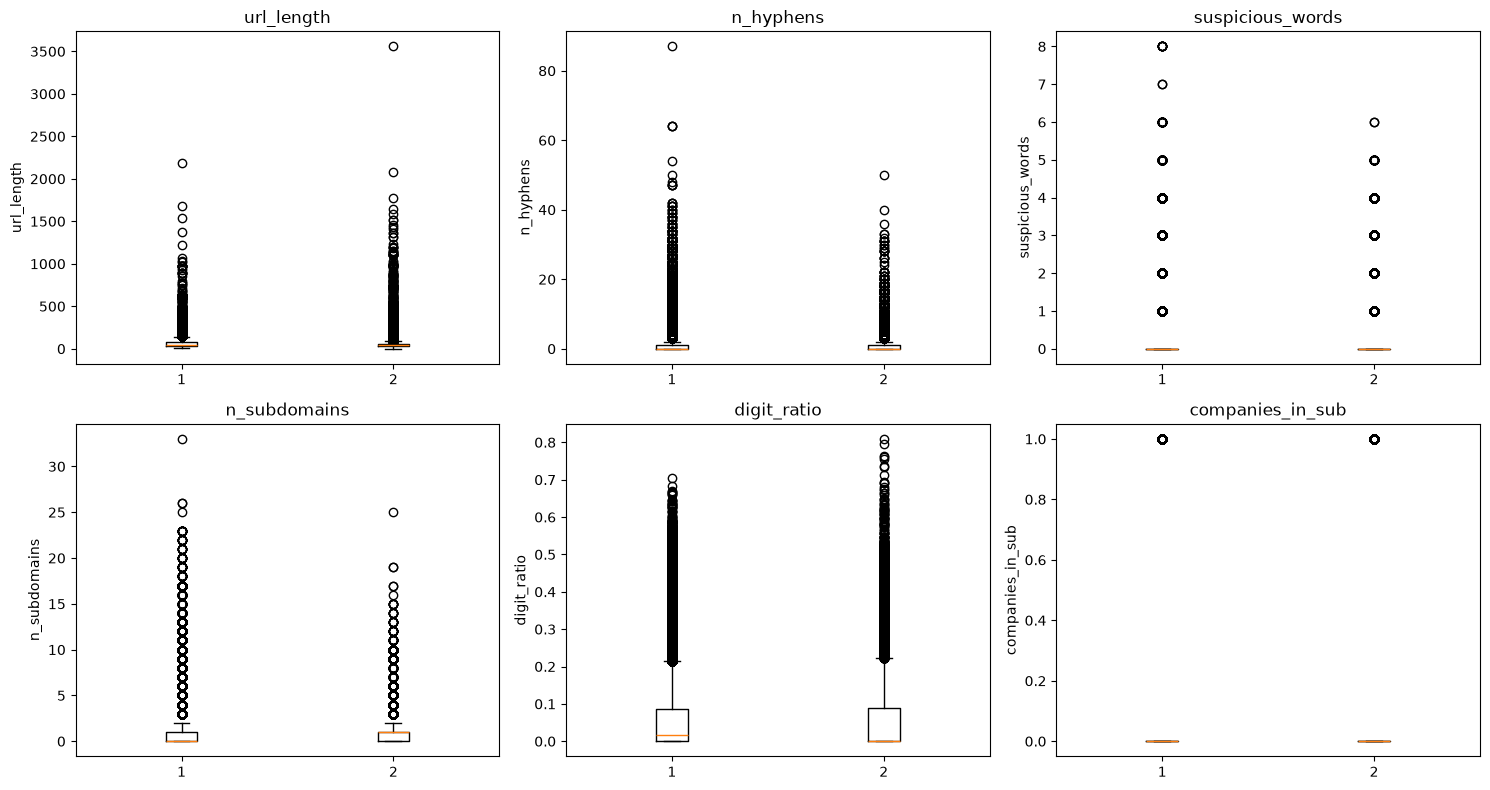

In [ ]:
# Box plot in columns 
import matplotlib.pyplot as plt

plot_features = ["url_length", "n_hyphens", "suspicious_words", "n_subdomains", "digit_ratio", "companies_in_sub"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(plot_features):
    ax = axes.flat[i]
    not_phishing = combined.loc[combined["label"] == 0, col]
    phishing = combined.loc[combined["label"] == 1, col]
    ax.boxplot([not_phishing, phishing], label=["Not phishing", "Phishing"])
    ax.set_title(col)
    ax.set_ylabel(col)
plt.tight_layout()
plt.savefig("data_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

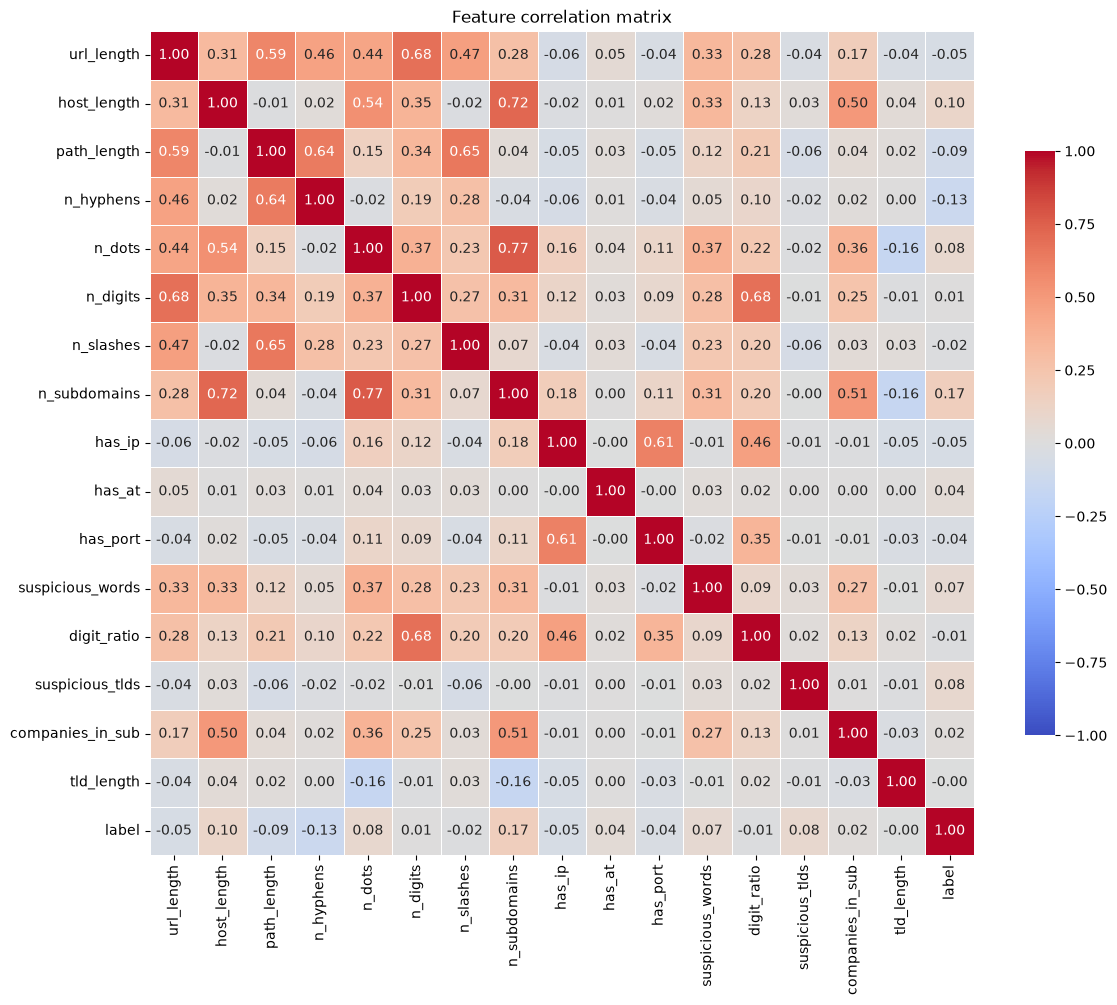

In [ ]:
#Heat map in columns 
import matplotlib.pyplot as plt
import seaborn as sns

feature_columns = [
    'url_length', 'host_length', 'path_length', 'n_hyphens', 'n_dots', 'n_digits', 'n_slashes', 'n_subdomains', 'has_ip', 'has_at', 'has_port', 'suspicious_words', 'digit_ratio', 'suspicious_tlds', 'companies_in_sub', 'tld_length'

]

corr_matrix = combined[feature_columns + ["label"]].corr()

plt.figure(figsize =(12, 10))
sns.heatmap(corr_matrix,
            cmap="coolwarm",
            center=0,
            vmin=-1, vmax=1,
            annot=True, fmt=".2f",
            square=True,
            cbar_kws={"shrink": 0.7},
            linewidths=0.5)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [110]:
#Ranked correlations
feature_columns = [
     'url_length', 'host_length', 'path_length', 'n_hyphens', 'n_dots',
    'n_digits', 'n_slashes', 'n_subdomains', 'has_ip', 'has_at',
    'has_port', 'suspicious_words', 'digit_ratio', 'suspicious_tlds',
    'companies_in_sub', 'tld_length'
]

corr_with_label = combined[feature_columns + ["label"]].corr()["label"].drop("label")
corr_sorted = corr_with_label.sort_values(key=abs, ascending=False)

print("Feature correlations with the phishing label ")
print(corr_sorted.round(3).to_string())
                     

Feature correlations with the phishing label 
n_subdomains        0.171
n_hyphens          -0.129
host_length         0.104
path_length        -0.087
n_dots              0.081
suspicious_tlds     0.080
suspicious_words    0.069
has_ip             -0.049
url_length         -0.048
has_at              0.043
has_port           -0.035
companies_in_sub    0.023
n_slashes          -0.016
digit_ratio        -0.012
n_digits            0.006
tld_length         -0.005
